In [1]:
#installation
# pip3 install torch torchvision (cpu)
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt
import pandas as pd 
from torch.random import manual_seed
import math

# Transformada Inversa

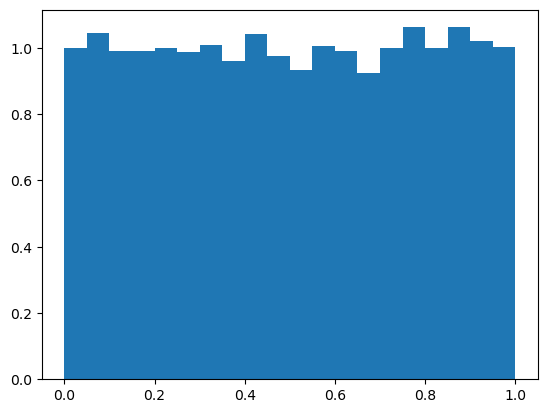

In [2]:
#Supongamos que solo sabemos simular uniformes
manual_seed(2**10)
n = 10000
u = torch.rand((n,))
plt.hist(u, bins=20, density=True)
plt.show()

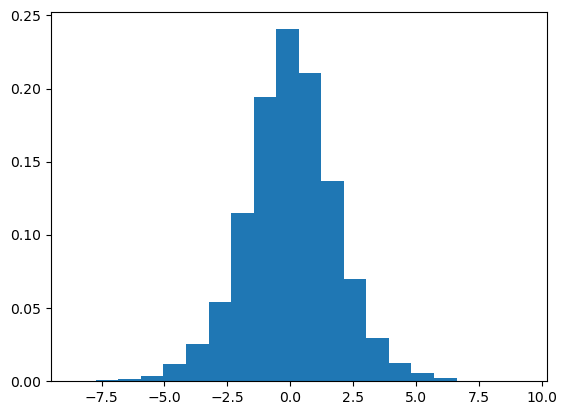

In [3]:
#simulamos de la Logística

x_logit = torch.logit(u)
plt.hist(x_logit, bins=20, density=True)
plt.show()

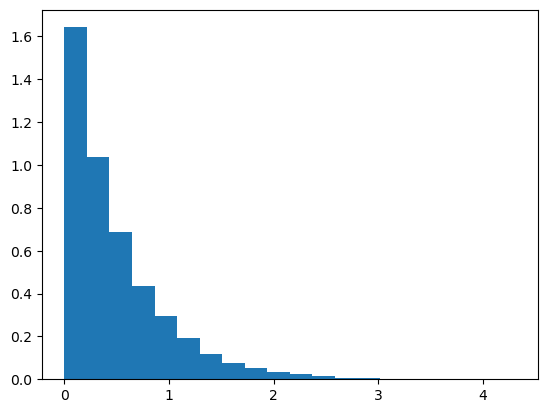

In [4]:
# Simulamos exponecial
lamb = 2.0
x_exp = -torch.log(u)/lamb
plt.hist(x_exp, bins=20, density=True)
plt.show()

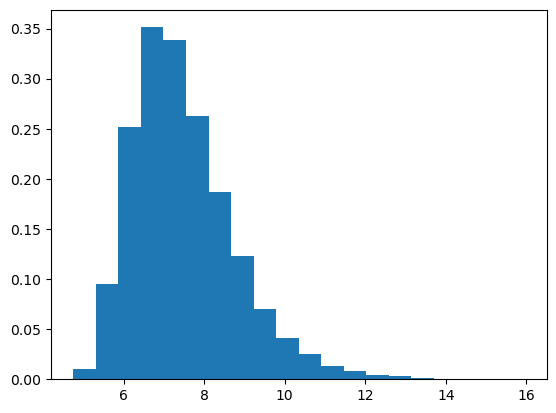

In [5]:
# Máximo de la logística tranformada inversa

k = 1000
x_max = torch.logit(u**(1/k))
plt.hist(x_max, bins=20, density=True)
plt.show()

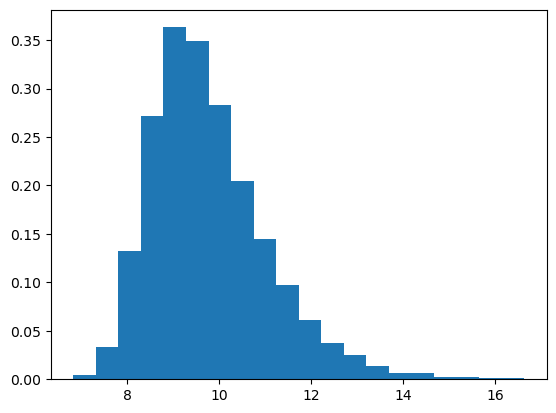

In [6]:
# Máximo de la logística usando máximo{x_1,..,x_k}
n_2 = 20000
k_2 = 10000

u_2 = torch.rand((n_2,k_2))

x_logit2 = torch.logit(u_2)
x_max2 = torch.max(x_logit2, dim=1).values

plt.hist(x_max2, bins=20, density=True)
plt.show()

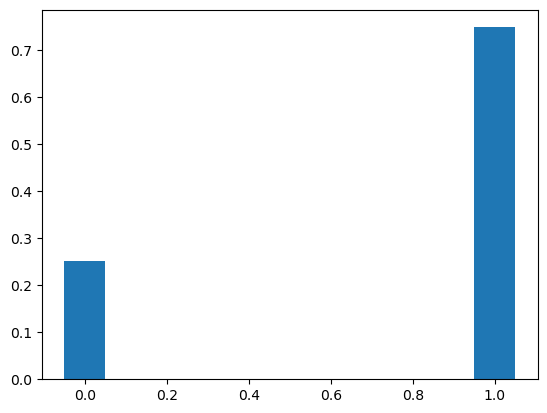

In [7]:
#Bernoulli
p = 3/4
x_ber = torch.where(u<1-p, 0.0, 1.0)

values, counts = torch.unique(x_ber, return_counts=True)
freq = counts / counts.sum()

plt.bar(values, freq, width=0.1)
plt.show()

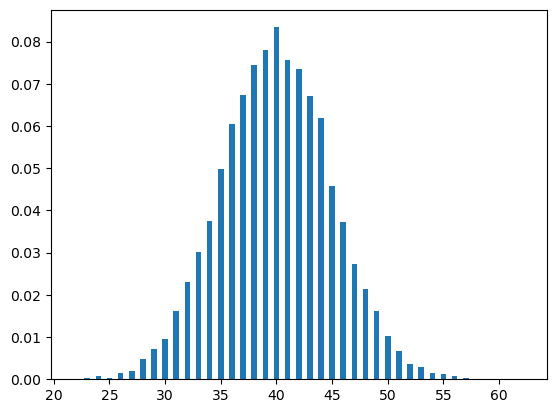

In [8]:
# Binomial(N,p)

N = 100
p = 2/5

a = -p/(1-p)
b = ((N+1)*p)/(1-p)
x_bin = []

for _ in range(n):
    
    p_0 = (1-p)**N
    S_p = p_0
    I = 0
    
    u_bin = torch.rand((1,)).item()
    
    while True:
    
        if u_bin < S_p:
    
            break
        else:
            
            I = I + 1 
            
            #if I > N:
                #I = N
                #break
                
            p_0 = p_0*(a+b/I)
            S_p = S_p + p_0

    x_bin.append(I)
        
x_bin = torch.Tensor(x_bin)

values, counts = torch.unique(x_bin, return_counts=True)
freq = counts / counts.sum()

plt.bar(values, freq, width=0.5)
plt.show()

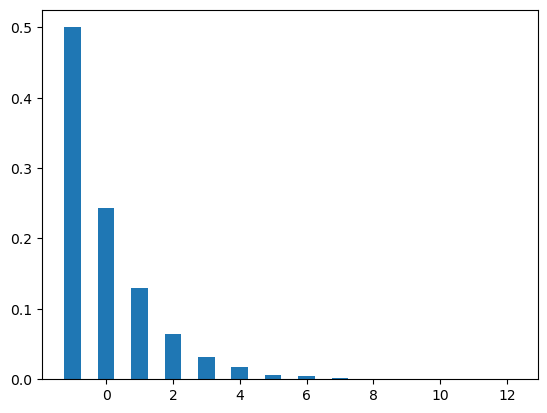

In [9]:
#Geometrica
p = 0.5
x_geo = torch.floor(torch.log(1-u)/torch.log(torch.tensor(1-p))-1)

values, counts = torch.unique(x_geo, return_counts=True)
freq = counts / counts.sum()

plt.bar(values, freq, width=0.5)
plt.show()

# Aceptación y Rechazo 

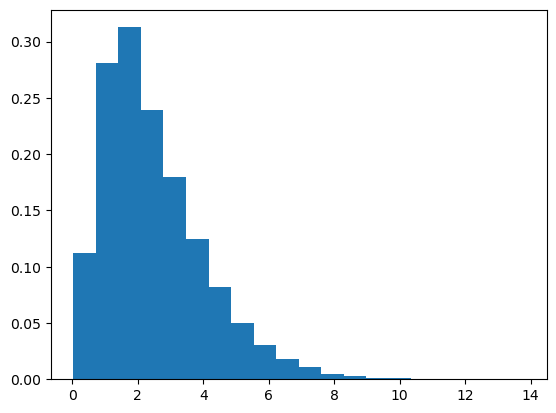

In [10]:
# Aceptación y Rechazo Gamma(alpha,1) alpha>1

alpha = 2.5
lamb = 1/alpha 

M = ((alpha-1)/(1-lamb))**(alpha-1)*math.exp(-alpha + 1)/(lamb*math.gamma(alpha))

def f_gamma(x):
    
    return (x ** (alpha - 1) * math.exp(-x)) / math.gamma(alpha)

def g_exp(x):
      
        return lamb * math.exp(-lamb * x)

muestras_aceptadas = []
intentos_totales = 0

while len(muestras_aceptadas) < n:
    
    intentos_totales += 1

    # Generar una propuesta Y de la distribución Exponencial(lamb)
    # Usamos el método de la transformada inversa: -ln(U)/lamb
    u1 = torch.rand((1,)).item()
    y = -math.log(u1) / lamb

    # Generar una variable uniforme para el criterio de rechazo
    u2 = torch.rand((1,)).item()

    # Condición de aceptación: U2 <= f(Y) / (M * g(Y))
    if u2 <= f_gamma(y) / (M * g_exp(y)):
        muestras_aceptadas.append(y)

x_gamma = torch.Tensor(muestras_aceptadas)
tasa_aceptacion = len(muestras_aceptadas) / intentos_totales
plt.hist(x_gamma, bins=20, density=True)
plt.show()

In [11]:
print(f"Tasa de aceptación teórica (1/M): {1/M:.4f}")
print(f"Tasa de aceptación simulada: {tasa_aceptacion:.4f}")


Tasa de aceptación teórica (1/M): 0.6029
Tasa de aceptación simulada: 0.5975


# Distribución Normal Estándar

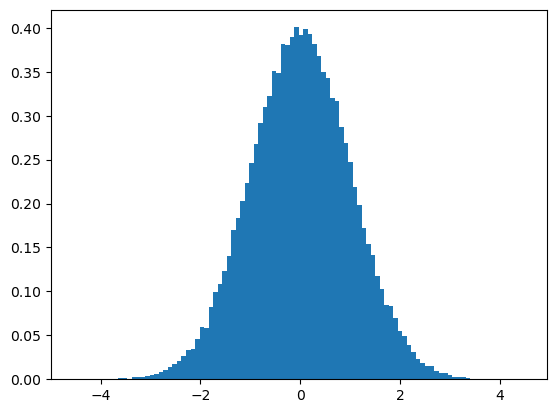

In [12]:
n = 100000

U_norm = torch.rand((n,2))

x1_norm = torch.sqrt(-2*torch.log(U_norm[:,0]))*torch.cos(2*torch.pi*U_norm[:,1])
x2_norm = torch.sqrt(-2*torch.log(U_norm[:,0]))*torch.sin(2*torch.pi*U_norm[:,1])

plt.hist(x1_norm,bins=100,density=True)
plt.show()

# Mezcla de Normales

In [13]:
p_mix = 0.3
probs = torch.Tensor([p_mix, 1-p_mix])

Z_cate = dist.Categorical(probs)
x_zcate = Z_cate.sample((n,))

mu = [-2, 4]
sigma = [1.2, 1.5]

z1_norm = x1_norm*sigma[0] + mu[0]
z2_norm = x2_norm*sigma[1] + mu[1] 

x_mix = torch.where(x_zcate==0, z1_norm, z2_norm)

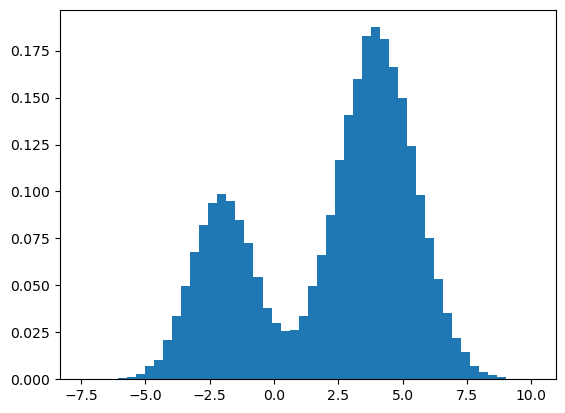

In [14]:
plt.hist(x_mix, bins=50, density=True)
plt.show()

In [15]:
#Mezclas con pytorch 
mix_dist = dist.Normal(torch.Tensor(mu),torch.Tensor(sigma)) 
         
norm_mix = dist.MixtureSameFamily(Z_cate, mix_dist)

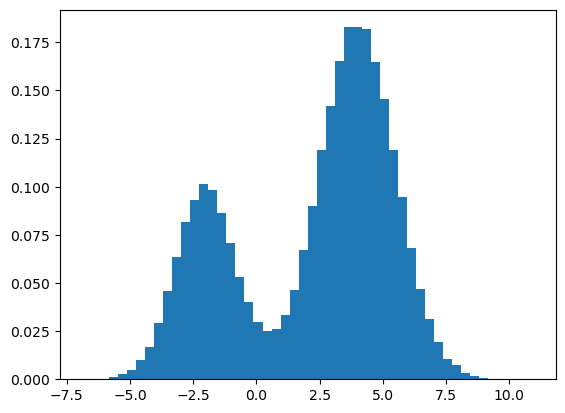

In [16]:
x_normmix = norm_mix.sample((n,))
plt.hist(x_normmix, bins=50, density=True)
plt.show()

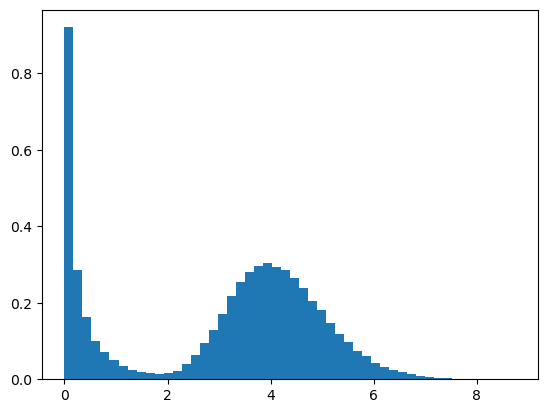

In [17]:
mix_dist_gam = dist.Gamma(torch.Tensor([0.5, 20.0]), torch.Tensor([1.5, 4.8])) 
         
gamm_mix = dist.MixtureSameFamily(Z_cate, mix_dist_gam)

x_gammmix = gamm_mix.sample((n,))
plt.hist(x_gammmix, bins=50, density=True)
plt.show()

# Vectores Aleatorios

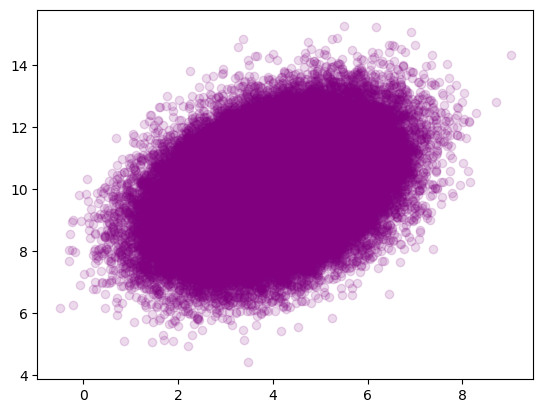

In [18]:
# Normal MUltivariada
mu = torch.Tensor([4, 10])
sigma = torch.Tensor([[1.2, 0.5], [0.5, 1.5]])

Mult_Norm = dist.MultivariateNormal(mu, sigma)

norm_mul_sample = Mult_Norm.sample((n,))

plt.scatter(norm_mul_sample[:,0], norm_mul_sample[:,1],alpha=0.15, 
            color='purple')
plt.show()

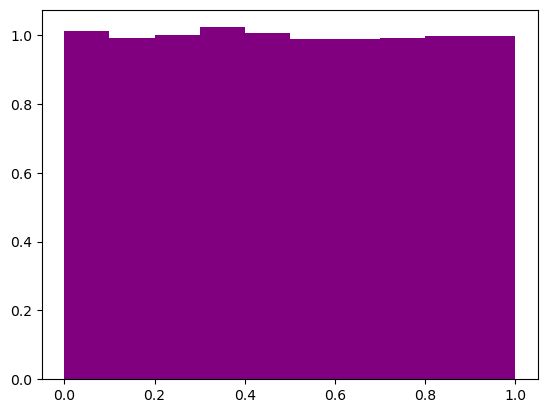

In [19]:
# Dirichlet 
alpha = torch.Tensor([1.0, 1.0])
Dirich = dist.Dirichlet(alpha)
dirich_samp = Dirich.sample((n,))

plt.hist(dirich_samp[:,0], color='purple', density=True)
plt.show()

In [20]:
#Normal INversa Gamma 

a = 8.5
b = 1.5
mu = torch.Tensor([4.5])

Y_gamma = dist.Gamma(a, b).sample((n,))

Varianza = 1.0 / Y_gamma
Desviacion = torch.sqrt(Varianza)

X_normal = dist.Normal(mu, Desviacion).sample()

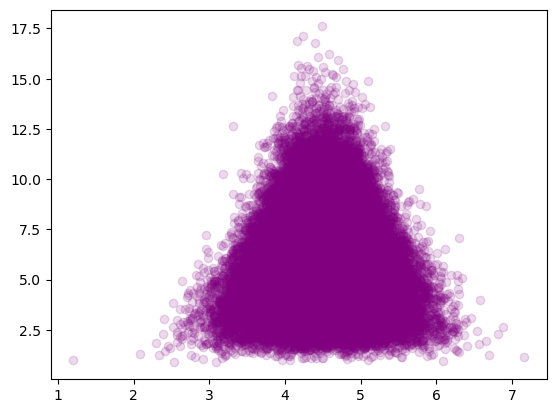

In [21]:
plt.scatter(X_normal, Y_gamma, alpha=0.15, 
            color='purple')
plt.show()

# Convergencia de Sucesiones 

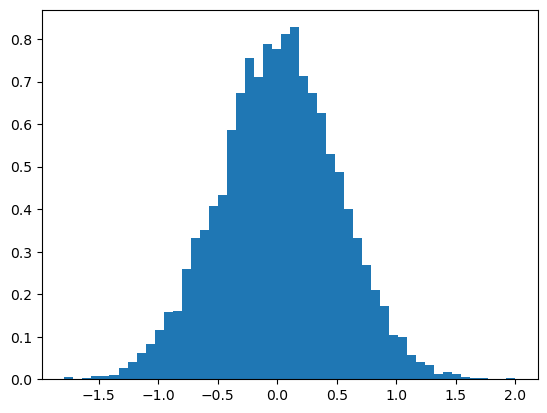

In [22]:
n_samples = 50000
trayectories = 10000
p = 0.5
Bern_dist = dist.Bernoulli(p)
bern_sample = Bern_dist.sample((n_samples,trayectories))

bern_sample_limit = math.sqrt(n_samples/p*(1-p))*(bern_sample.mean(dim=0)-p)
plt.hist(bern_sample_limit, bins=50, density=True)
plt.show()

In [23]:
bern_seq = bern_sample.cumsum(dim=0) / torch.arange(1, n_samples+1).unsqueeze(1)

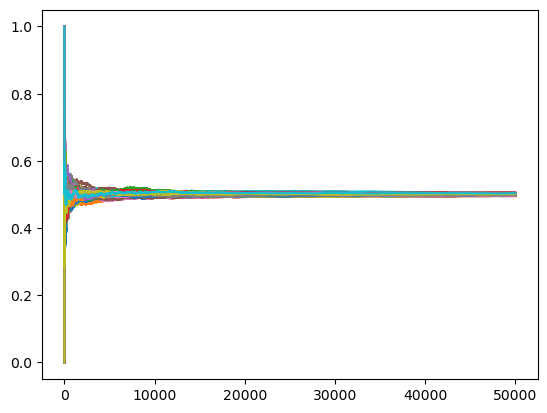

In [31]:
pd.DataFrame(bern_seq[:,:100]).plot(subplots=False, legend=False)
plt.show()

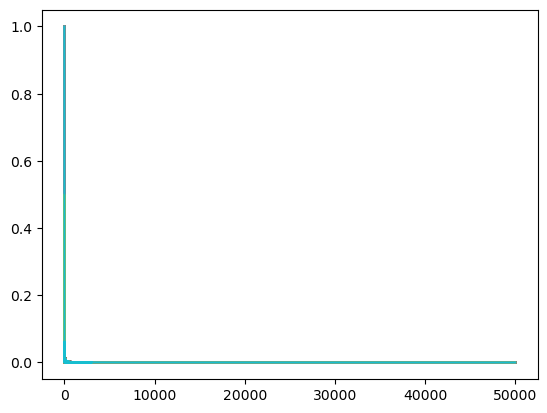

In [45]:
b_n = bern_sample[:,:100]/torch.arange(1, n_samples+1).unsqueeze(1)
pd.DataFrame(b_n[:,:100]).plot(subplots=False, legend=False)
plt.show()